In [24]:
from bandits.egreedy_bandit import EGreedyLearner
from bandits.explore_then_commit_bandit import ExploreThenCommitLearner
from bandits.thompson_sampling_bandit import ThompsonSamplingLearner
from bandits.ucb_bandit import UCBLearner
from bandits.gradient_bandit import GradientLearner

from environment.environment import BanditLearner, KArmedBandit

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import random
from itertools import accumulate

In [26]:
class BanditProblem:
    def __init__(self, time_steps: int, bandit: KArmedBandit, learner: BanditLearner):
        self.time_steps: int = time_steps
        self.bandit: KArmedBandit = bandit
        self.learner: BanditLearner = learner
        self.learner.reset(self.bandit.arms(), self.time_steps)

    def run(self) -> list[float]:
        rewards = []
        for _ in range(self.time_steps):
            arm = self.learner.pick_arm()
            reward = self.bandit.reward(arm)
            self.learner.acknowledge_reward(arm, reward)
            rewards.append(reward)
        return rewards

In [27]:
POTENTIAL_HITS = {
    "In Praise of Dreams": 0.8,
    "We Built This City": 0.9,
    "April Showers": 0.5,
    "Twenty Four Hours": 0.3,
    "Dirge for November": 0.1,
}

def random_potential_hits(num_arms: int = 5) -> dict[str, float]:
    return {f"Song {i+1}": random.random() for i in range(num_arms)}

class TopHitBandit(KArmedBandit):
    def __init__(self, potential_hits: dict[str, float]):
        self.potential_hits: dict[str, float] = potential_hits

    def arms(self) -> list[str]:
        return list(self.potential_hits)

    def reward(self, arm: str) -> float:
        thumb_up_probability = self.potential_hits[arm]
        return 1.0 if random.random() <= thumb_up_probability else 0.0
#

class RandomLearner(BanditLearner):
    def __init__(self):
        self.name = "random"
        self.color = "black"
        self.arms: list[str] = []

    def reset(self, arms: list[str], time_steps: int):
        self.arms = arms

    def pick_arm(self) -> str:
        return random.choice(self.arms)

    def acknowledge_reward(self, arm: str, reward: float) -> None:
        pass
#

In [28]:
TIME_STEPS = 1000
TRIALS_PER_LEARNER = 2000

In [29]:
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'cyan']

In [30]:
def evaluate_learner(learner: BanditLearner, color, ax_reward=None, ax_regret=None) -> None:
    runs_rewards = []
    runs_regret = []

    for _ in range(TRIALS_PER_LEARNER):
        bandit = TopHitBandit(random_potential_hits())
        problem = BanditProblem(time_steps=TIME_STEPS, bandit=bandit, learner=learner)
        rewards = problem.run()

        accumulated_rewards = list(accumulate(rewards))
        runs_rewards.append(accumulated_rewards)

        best_reward = max(bandit.potential_hits.values())
        regrets = [best_reward - r for r in rewards]
        cumulative_regret = list(accumulate(regrets))
        runs_regret.append(cumulative_regret)

    mean_rewards = np.mean(np.array(runs_rewards), axis=0)
    mean_regret = np.mean(np.array(runs_regret), axis=0)

    param_str = ''
    if hasattr(learner, 'c'):
        param_str = f" c={learner.c}"
    elif hasattr(learner, 'alpha'):
        param_str = f" alpha={learner.alpha}"
    elif hasattr(learner, 'eps'):
        param_str = f" eps={learner.eps}"
    elif hasattr(learner, 'm'):
        param_str = f" m={learner.m}"

    label = f"{learner.name}{param_str}"

    if ax_reward is not None:
        ax_reward.plot(mean_rewards, label=label, color=color)
    if ax_regret is not None:
        ax_regret.plot(mean_regret, label=label, color=color)


def setup_axes(ax_reward=None, ax_regret=None):
    if ax_reward is not None:
        ax_reward.set_xlabel('Czas')
        ax_reward.set_ylabel('Suma uzyskanych nagród')
        ax_reward.set_xlim(0, TIME_STEPS)
        ax_reward.set_ylim(0, TIME_STEPS)
        ax_reward.legend()
    if ax_regret is not None:
        ax_regret.set_xlabel('Czas')
        ax_regret.set_ylabel('Skumulowany regret')
        ax_regret.set_xlim(0, TIME_STEPS)
        ax_regret.legend()
#

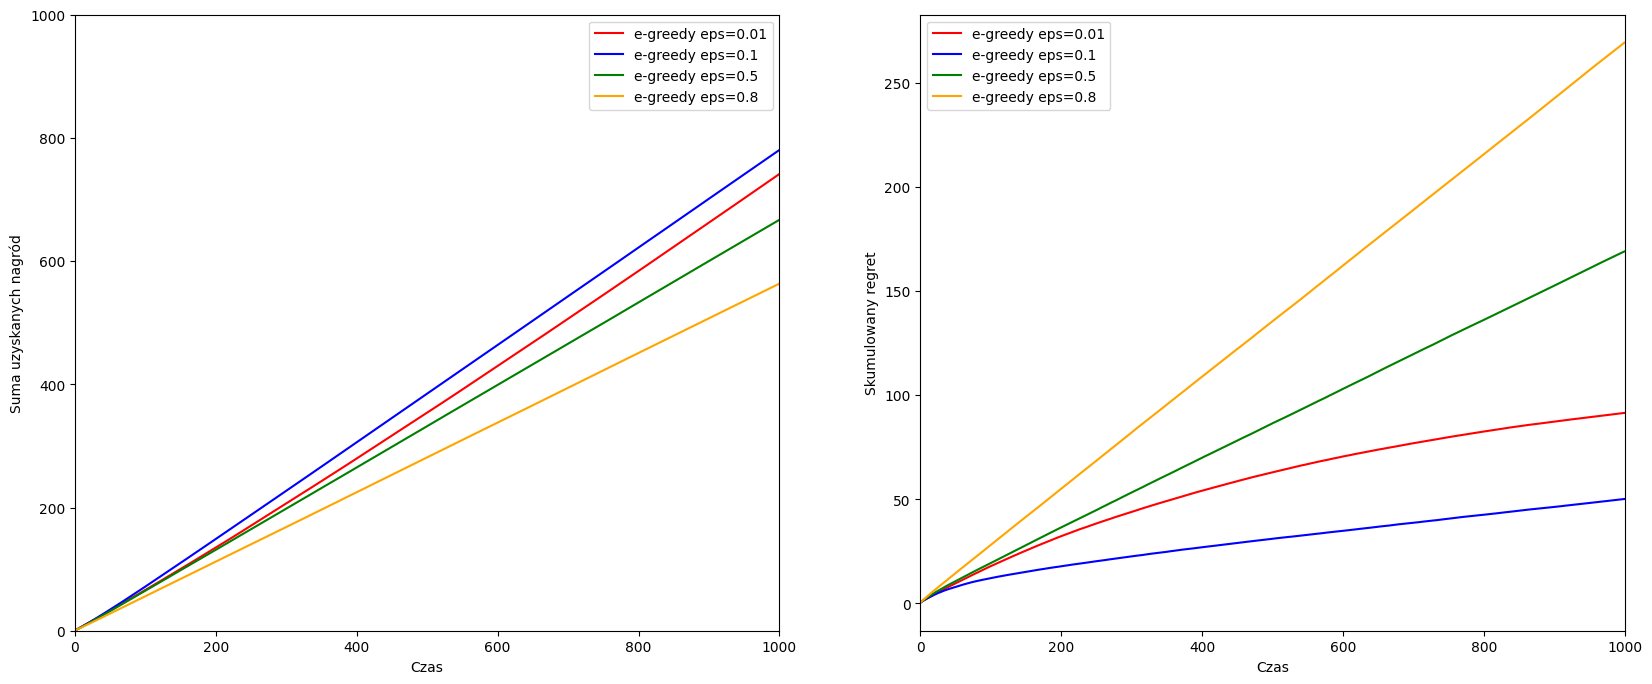

In [31]:
learners = [
    EGreedyLearner(eps=0.01),
    EGreedyLearner(eps=0.1),
    EGreedyLearner(eps=0.5),
    EGreedyLearner(eps=0.8)
]
fig, (ax_reward, ax_regret) = plt.subplots(1, 2, figsize=(20, 8))

for learner, color in zip(learners, colors):
    evaluate_learner(learner, color=color, ax_reward=ax_reward, ax_regret=ax_regret)

setup_axes(ax_reward, ax_regret)
plt.show()

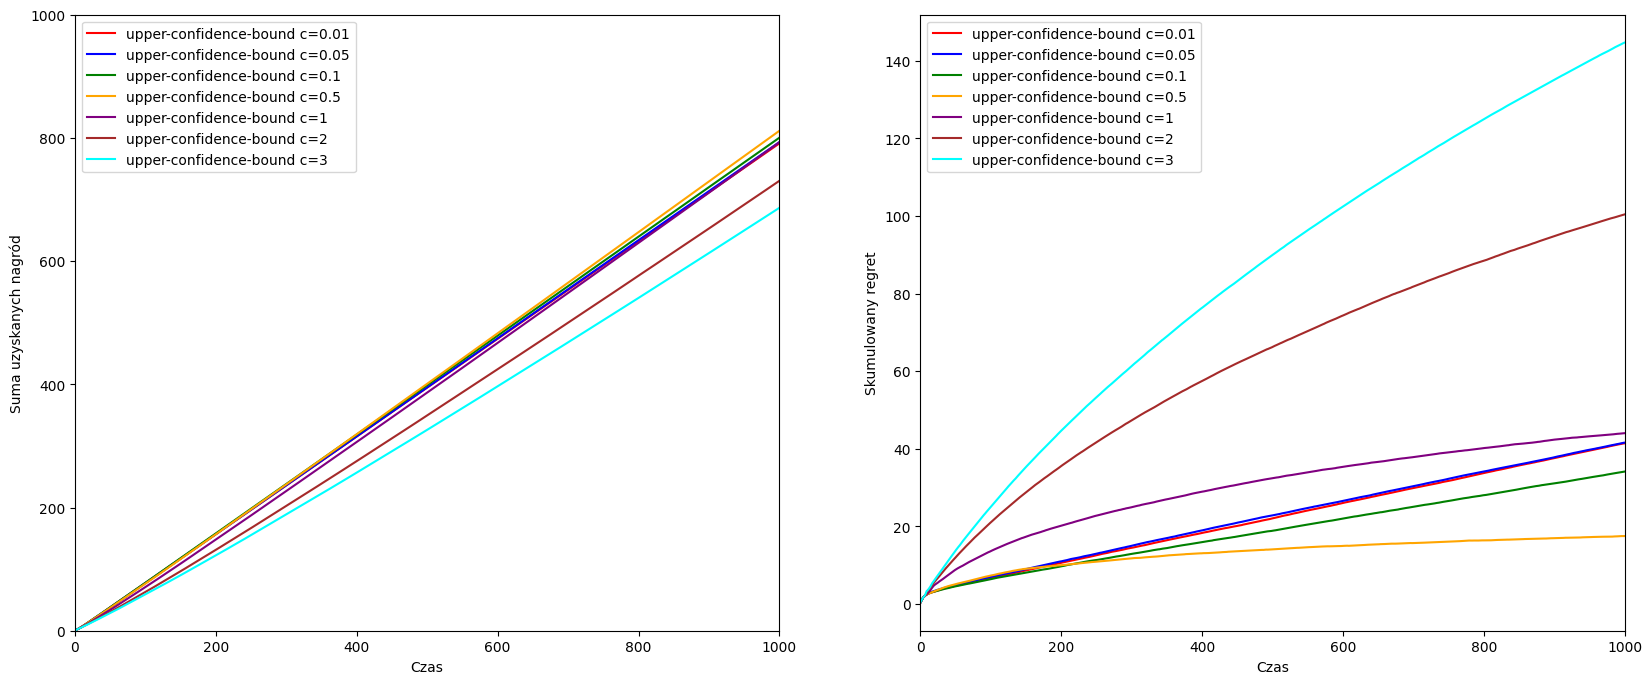

In [32]:
learners = [
    UCBLearner(c=0.01),
    UCBLearner(c=0.05),
    UCBLearner(c=0.1),
    UCBLearner(c=0.5),
    UCBLearner(c=1),
    UCBLearner(c=2),
    UCBLearner(c=3),
]
fig, (ax_reward, ax_regret) = plt.subplots(1, 2, figsize=(20, 8))

for learner, color in zip(learners, colors):
    evaluate_learner(learner, color=color, ax_reward=ax_reward, ax_regret=ax_regret)

setup_axes(ax_reward, ax_regret)
plt.show()

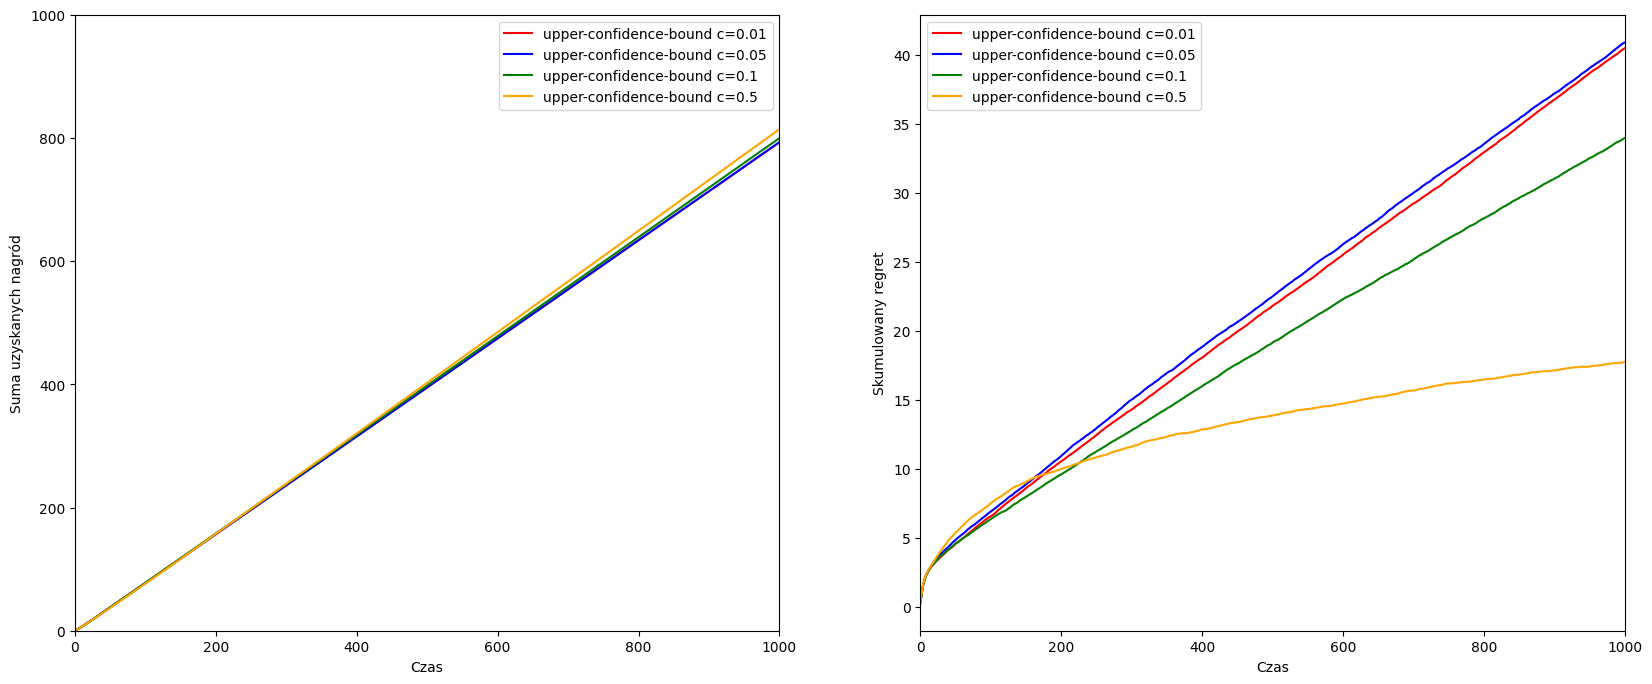

In [33]:
learners = [
    UCBLearner(c=0.01),
    UCBLearner(c=0.05),
    UCBLearner(c=0.1),
    UCBLearner(c=0.5),
]
fig, (ax_reward, ax_regret) = plt.subplots(1, 2, figsize=(20, 8))

for learner, color in zip(learners, colors):
    evaluate_learner(learner, color=color, ax_reward=ax_reward, ax_regret=ax_regret)

setup_axes(ax_reward, ax_regret)
plt.show()

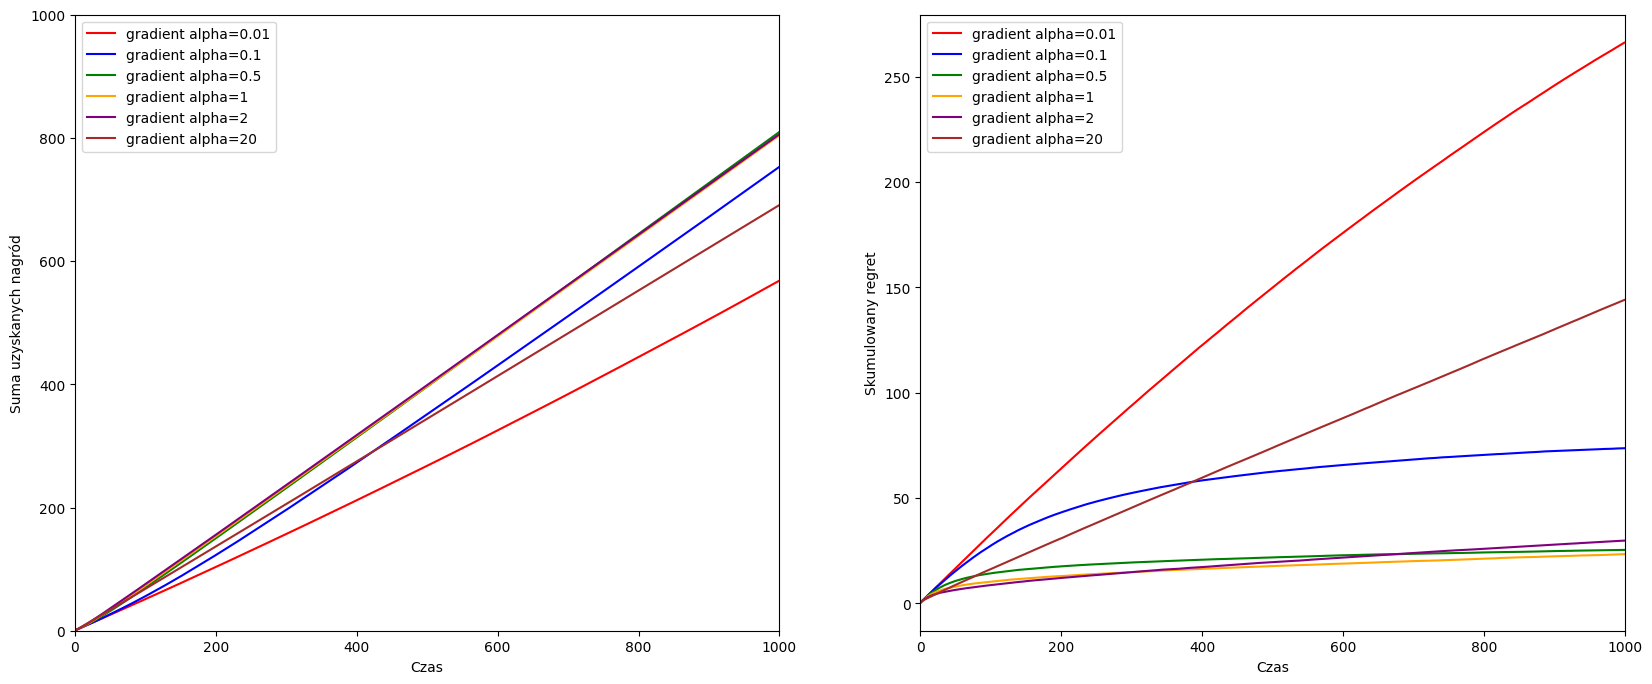

In [34]:
learners = [
    GradientLearner(alpha=0.01),
    GradientLearner(alpha=0.1),
    GradientLearner(alpha=0.5),
    GradientLearner(alpha=1),
    GradientLearner(alpha=2),
    GradientLearner(alpha=20),
]
fig, (ax_reward, ax_regret) = plt.subplots(1, 2, figsize=(20, 8))

for learner, color in zip(learners, colors):
    evaluate_learner(learner, color=color, ax_reward=ax_reward, ax_regret=ax_regret)

setup_axes(ax_reward, ax_regret)
plt.show()

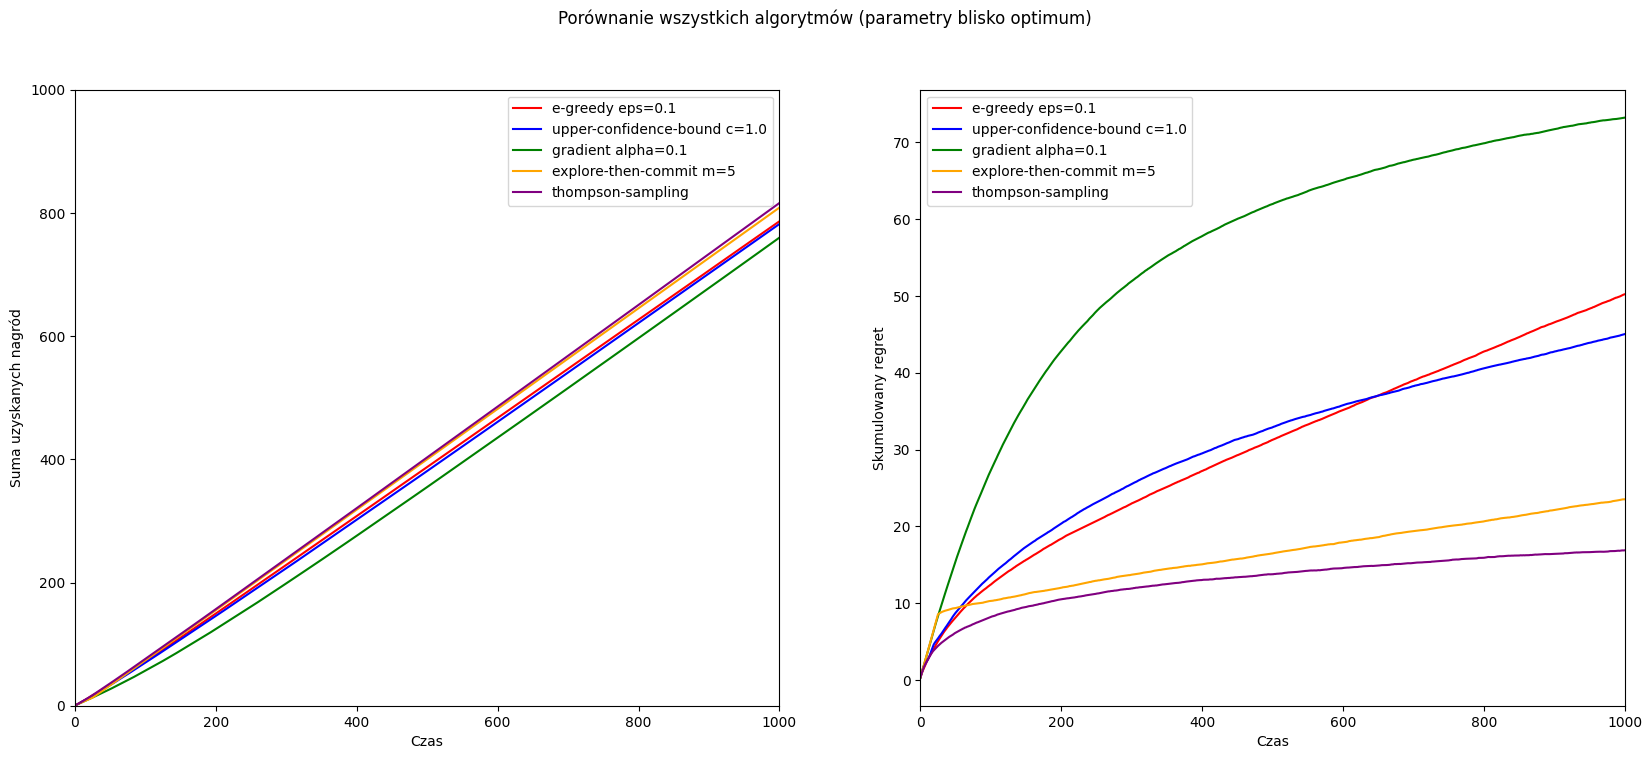

In [35]:
learners = [
    EGreedyLearner(eps=0.1),
    UCBLearner(c=1.0),
    GradientLearner(alpha=0.1),
    ExploreThenCommitLearner(m=5),
    ThompsonSamplingLearner(),
]
fig, (ax_reward, ax_regret) = plt.subplots(1, 2, figsize=(20, 8))

for learner, color in zip(learners, colors):
    evaluate_learner(learner, color=color, ax_reward=ax_reward, ax_regret=ax_regret)

setup_axes(ax_reward, ax_regret)
fig.suptitle("Porównanie wszystkich algorytmów (parametry blisko optimum)")
plt.show()